<a href="https://colab.research.google.com/github/karthik1338/geeksforgeeks/blob/main/day_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Comprehension of Intelligent Document Processing

Intelligent Document Processing (IDP) is an advanced automation technology that transforms the way businesses handle documents. By leveraging artificial intelligence (AI), IDP systems can automatically read, understand, and process vast quantities of documents, extracting crucial data and feeding it into various business workflows. This technology is a significant leap from traditional Optical Character Recognition (OCR) as it not only digitizes text but also comprehends the context and structure of the information within documents.

At its core, IDP is designed to tackle the challenge of processing unstructured and semi-structured data, which make up a large portion of business documents such as invoices, contracts, emails, and forms. By automating the extraction and interpretation of this data, IDP significantly reduces the need for manual data entry, leading to increased efficiency, higher accuracy, and substantial cost savings.

<br><br>

---
<br><br>

### The Inner Workings of Intelligent Document Processing

The power of IDP lies in its sophisticated multi-step process that intelligently handles documents from ingestion to data delivery. This process typically involves several key stages:

**1. Document Ingestion:** The first step involves importing documents from various sources and in multiple formats, including scanned paper documents, PDFs, Word files, and images.

**2. Pre-processing:** To enhance the quality of the input, documents undergo a pre-processing stage. This includes techniques like noise reduction, image enhancement, and deskewing to improve the accuracy of subsequent data extraction.

**3. Document Classification:** Using machine learning algorithms, the IDP system automatically categorizes documents based on their layout and content. This allows the system to differentiate between an invoice, a purchase order, or a legal contract, for instance.

**4. Data Extraction:** This is the core function of IDP. Advanced AI technologies, including Natural Language Processing (NLP) and computer vision, are employed to identify and extract relevant data fields. For example, from an invoice, it can pull out the invoice number, date, vendor name, and line-item details.

**5. Data Validation:** The extracted data is then validated against predefined rules and existing databases to ensure accuracy and consistency. Any exceptions or discrepancies can be flagged for human review in a "human-in-the-loop" process, which also helps to train and improve the AI model over time.

**6. Integration:** Finally, the structured and validated data is seamlessly integrated into downstream business systems such as Enterprise Resource Planning (ERP), Customer Relationship Management (CRM), or other databases, making the information readily available for further processing and analysis.


From **finance departments** automating invoice processing and expense management to **healthcare organizations** streamlining patient record management and claims processing, IDP is proving to be a game-changer. Even  **human resources** can expedite resume screening and employee onboarding. As the technology continues to evolve, its applications are expected to expand even further, solidifying its role as a cornerstone of modern digital transformation.

# Our Approach

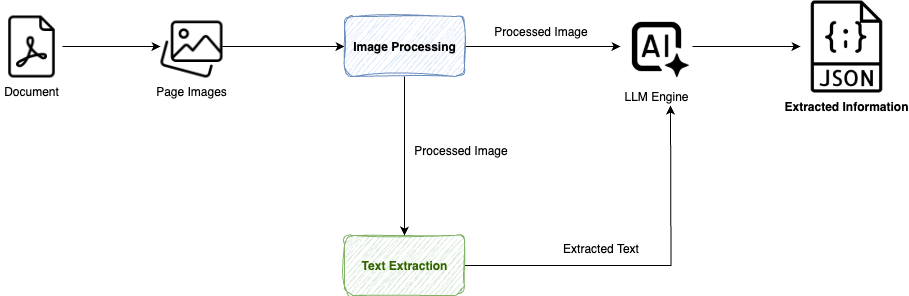

# Submission Can you play with a Resume Dataset?

https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset

## Getting the data

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'resume-dataset' dataset.
Path to dataset files: /kaggle/input/resume-dataset


In [62]:
! ls /kaggle/input/resume-dataset/data/data/ENGINEERING/

10030015.pdf  17043822.pdf  24322804.pdf  30542184.pdf	47919212.pdf
10219099.pdf  17103000.pdf  24647794.pdf  31677347.pdf	49127329.pdf
10624813.pdf  17108676.pdf  25425322.pdf  31684925.pdf	50328713.pdf
10712803.pdf  17488801.pdf  25608963.pdf  31694970.pdf	51588273.pdf
10985403.pdf  17926546.pdf  25797445.pdf  32081266.pdf	54227873.pdf
11890896.pdf  18753367.pdf  25919149.pdf  32802563.pdf	55595908.pdf
11981094.pdf  19124258.pdf  25930778.pdf  32985311.pdf	55953734.pdf
12011623.pdf  19396040.pdf  26456899.pdf  33685075.pdf	56691064.pdf
12022566.pdf  19397727.pdf  26834746.pdf  35172961.pdf	60004873.pdf
12472574.pdf  19553067.pdf  27040860.pdf  35389360.pdf	61579998.pdf
12488356.pdf  19612167.pdf  27152464.pdf  35651876.pdf	62071407.pdf
12518008.pdf  20566550.pdf  27756469.pdf  35737840.pdf	64468610.pdf
12748557.pdf  20882041.pdf  28005884.pdf  36149549.pdf	64755882.pdf
13149176.pdf  20981299.pdf  28078163.pdf  36517781.pdf	74236636.pdf
13264796.pdf  21038022.pdf  28320387.pdf  373353

Since these are single-paged images already, we don't need to convert them

## Understanding the data


The downloaded dataset contains two major folders:
1. **train**: This folder contains the training data.
2. **test**: This folder contains the test data.

Each of these folders contains the following subfolders:
1. **img**: This folder containing the images of the receipts.
2. **box**: This folder containing the bounding box information of the text in the images and the text inside the bounding boxes. The file is a text file with the same name as the image file but with a .txt extension. The format of the file is as follows:
    ```
    x1, y1, x2, y2, x3, y3, x4, y4, text
    ```
    where (x1, y1), (x2, y2), (x3, y3), and (x4, y4) are the coordinates of the bounding box and text is the text inside the bounding box.
3. **entities**: This folder contains the ground truth information of the entities in the receipts. The file is a text file with the same name as the image file but with a .txt extension. The file contains json data with the following format:
    ```json
    {
        "company": "COMPANY_NAME",
        "date": "DATE",
        "address": "ADDRESS",
        "total": "TOTAL",
    }
    ```

## Image Preprocesing: OpenCV

In [2]:
! pip install opencv-python matplotlib numpy

Let's take one image and play with it.

In [55]:
import os
one_image_path = os.path.join(path,'data','data','ENGINEERING','10030015.pdf')

#convert pdf to jpg formate

In [17]:
!pip install pdf2image
!sudo apt-get install poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.10 [186 kB]
Fetched 186 kB in 0s (920 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package poppler-utils.
(Reading database ... 126441

In [60]:
# Example usage: Convert the previously identified PDF file
output_images_folder = "/content/converted_images"
os.makedirs(output_images_folder, exist_ok=True)

# This is the path to the PDF file from the earlier cell
pdf_file_path = os.path.join(path,'data','data','ENGINEERING','10030015.pdf')

# Convert the PDF to an image
converted_image_path = convert_pdf_to_image(pdf_file_path, output_images_folder)

# Update the one_image_path variable to the newly created image path
if converted_image_path:
  one_image_path = converted_image_path
  print(f"Updated one_image_path to: {one_image_path}")
else:
  print("PDF conversion failed.")

Converted /kaggle/input/resume-dataset/data/data/FITNESS/16474898.pdf to /content/converted_images/16474898.jpg
Updated one_image_path to: /content/converted_images/16474898.jpg


# explore the transision for one image

In [56]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def display_image(image, title="Image"):
    plt.figure(figsize=(7, 7))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

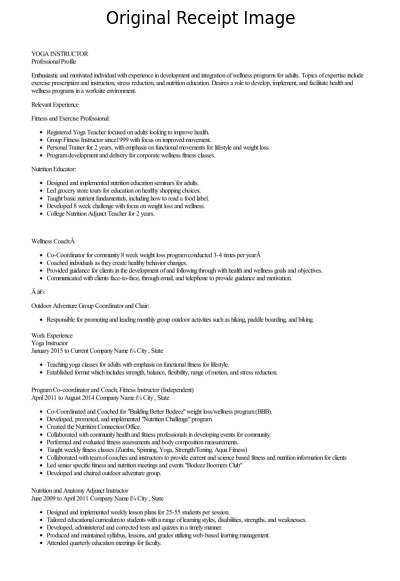

In [63]:
one_image = cv2.imread(one_image_path)
display_image(one_image, "Original Receipt Image")

### Grayscale Conversion

**Why?** Color information is usually not necessary for reading the text on a receipt. Converting the image to grayscale simplifies it from three color channels (Red, Green, Blue) to a single channel (intensity/brightness). This reduces computational complexity and is a required first step for many subsequent operations like thresholding.

In [18]:
from pdf2image import convert_from_path

def convert_pdf_to_image(pdf_path, output_folder):
    """Converts a single-page PDF to a JPG image."""
    try:
        # Convert the PDF to a list of images (one image per page)
        images = convert_from_path(pdf_path, first_page=1, last_page=1)

        if images:
            # Save the first (and only) image as a JPG
            image_name = os.path.basename(pdf_path).replace(".pdf", ".jpg")
            output_path = os.path.join(output_folder, image_name)
            images[0].save(output_path, 'JPEG')
            print(f"Converted {pdf_path} to {output_path}")
            return output_path
        else:
            print(f"No images found in {pdf_path}")
            return None
    except Exception as e:
        print(f"Error converting {pdf_path}: {e}")
        return None

Now that the PDF is converted to a JPG, we can try displaying it again.

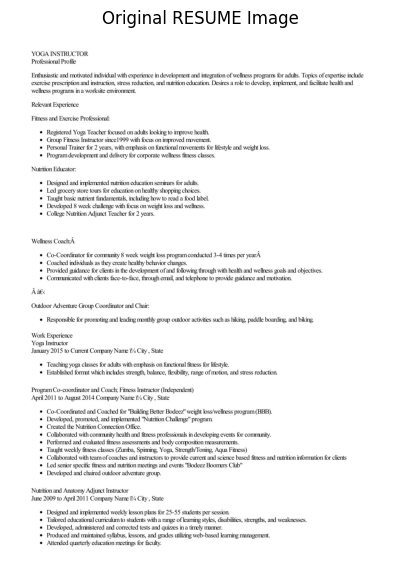

In [61]:
one_image = cv2.imread(one_image_path)
display_image(one_image, "Original RESUME Image")

In [22]:
# Convert the image to grayscale
def convert_to_grayscale(image):
  return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

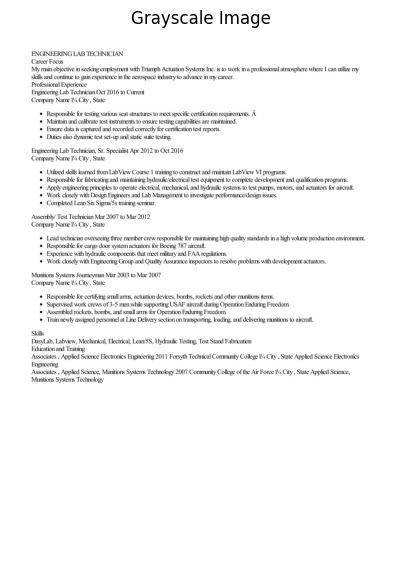

In [23]:
grayscale_image = convert_to_grayscale(one_image)
display_image(grayscale_image, "Grayscale Image")

### Noise (blur) Reduction
**Why?** Scanned images or photos often contain "noise" (random variations in brightness or color). This can look like small specks or graininess, which can confuse OCR algorithms. Applying a slight blur helps to smooth out this noise. A **Gaussian blur** is a common choice as it effectively averages out pixel values with a weighted average, preserving edges better than a simple blur.

In [24]:
def reduce_noise(gray_image):
  return cv2.GaussianBlur(gray_image, (5, 5), 0)

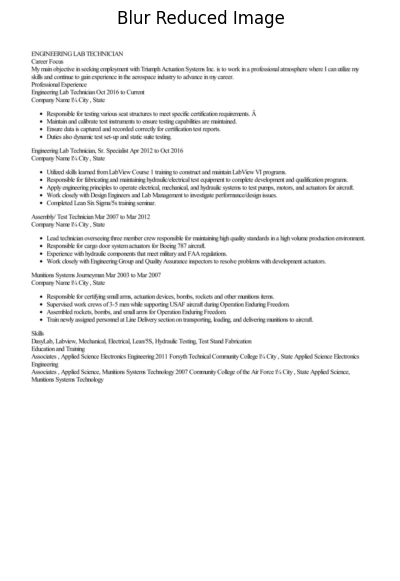

In [25]:
blur_reduced_image = reduce_noise(grayscale_image)
display_image(blur_reduced_image, "Blur Reduced Image")

### Binarization (Thresholding)

**Why?** This is one of the most critical steps. Binarization converts the grayscale image into a pure black-and-white image. The goal is to make the text **black** and the background **white**. However, receipts often have uneven lighting or shadows, so a simple (global) threshold won't work well. We use **adaptive thresholding**, which calculates a different threshold for smaller regions of the image, making it robust to lighting changes.

`cv2.adaptiveThreshold()`:

  * `cv2.ADAPTIVE_THRESH_GAUSSIAN_C`: Calculates the threshold for a pixel based on a weighted sum of neighborhood values.
  * `cv2.THRESH_BINARY_INV`: Inverts the result. We want the text to be white pixels (value 255) and the background black (value 0) for the next step (skew correction), which often works by finding white pixel contours.
  * `11`: The size of the neighborhood area (block size).
  * `4`: A constant subtracted from the mean. It's a fine-tuning parameter.

In [26]:
def binarize_image(blur_reduced_image):
  return cv2.adaptiveThreshold(
    blur_reduced_image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, # Invert the colors (text becomes white)
    11, # Block size
    4  # Constant C
  )

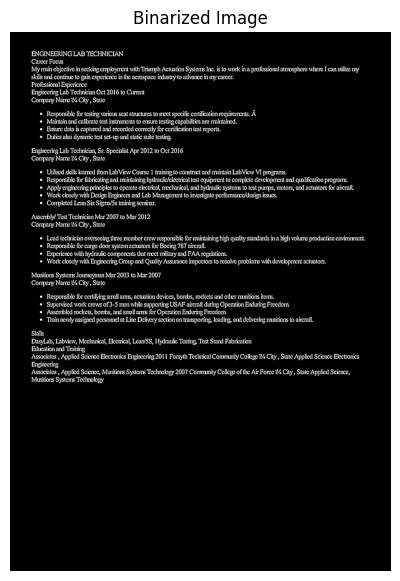

In [27]:
binarized_image = binarize_image(blur_reduced_image)
display_image(binarized_image, "Binarized Image")

### Skew Correction

**Why?** Receipts are often scanned or photographed at a slight angle. This skew can significantly reduce the accuracy of OCR. We need to detect this angle and rotate the image to make the text perfectly horizontal.

A common technique is to find the angle of the minimum-area bounding box that encloses all the text (the white pixels in our binarized image) and then rotate the original image by that angle.

In [28]:
def deskew_image(image):
    """
    Corrects the skew of an image by finding the minimum area rectangle
    of the text block and rotating accordingly.
    """
    # Find all non-zero (white) pixels
    coords = cv2.findNonZero(image)

    # Get the minimum area bounding rectangle
    # It returns (center(x,y), (width, height), angle of rotation)
    rect = cv2.minAreaRect(coords)
    angle = rect[-1] - 90

    # The `cv2.minAreaRect` angle has a specific range.
    # We need to adjust it for our rotation.
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = angle

    # Get the rotation matrix and rotate the image
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h),
                             flags=cv2.INTER_CUBIC,
                             borderMode=cv2.BORDER_REPLICATE)
    print(f"Detected skew angle: {angle:.2f} degrees")

    # Now, rotate the original grayscale image by the same angle
    (h, w) = rotated.shape
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    deskewed_gray = cv2.warpAffine(rotated, M, (w, h),
                                  flags=cv2.INTER_CUBIC,
                                  borderMode=cv2.BORDER_REPLICATE)

    return deskewed_gray

In [29]:
deskewed_image = deskew_image(binarized_image)

Detected skew angle: 0.00 degrees


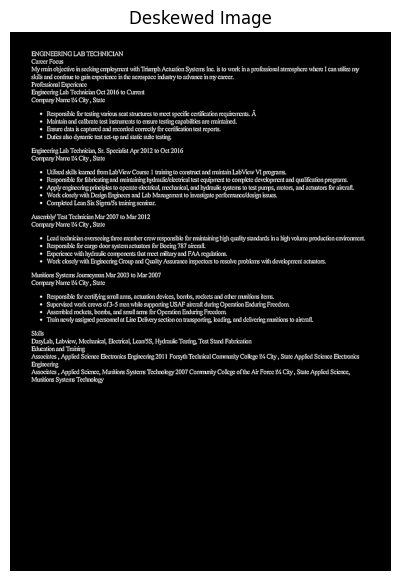

In [30]:
display_image(deskewed_image, "Deskewed Image")

# Taking 5 resume in pdf -> jpg -> json using llm

In [31]:
def process_one_image(image):
  image = convert_to_grayscale(image)
  print("Converted image to grayscale..")
  image = reduce_noise(image)
  print("Reduced noise in the image..")
  image = binarize_image(image)
  print("Binarized the image..")
  image = deskew_image(image)
  print("Corrected image orientation..")
  return image

In [33]:
import time
output_folder_path = "/content/processed_images"
start_time = time.time()

if os.makedirs(output_folder_path, exist_ok=True):
  print(f"Created folder: {output_folder_path}")

# Get the list of PDF files in the ENGINEERING directory
pdf_files = [f for f in os.listdir(os.path.join(path,'data','data','ENGINEERING')) if f.endswith('.pdf')][:20]

total_images = len(pdf_files)
print(f"Total PDF files to process: {total_images}")


for i, image_name in enumerate(pdf_files, 1):
  print(f"Processing image {i}/{total_images}: {image_name}")
  pdf_file_path = os.path.join(path, 'data', 'data', 'ENGINEERING', image_name)

  # Convert the PDF to an image
  converted_image_path = convert_pdf_to_image(pdf_file_path, output_images_folder)

  if converted_image_path:
    image = cv2.imread(converted_image_path)
    processed_image = process_one_image(image)
    # save image with .jpg extension
    output_path = os.path.join(output_folder_path, image_name.replace(".pdf", ".jpg"))
    cv2.imwrite(output_path, processed_image)
    print(f"Saved processed image to: {output_path}")
    print("-"*50)
  else:
    print(f"Skipping {image_name} due to conversion error.")
    print("-"*50)


print("Processing images is completed.")
print(f"Total time taken: {time.time() - start_time} seconds")

Total PDF files to process: 20
Processing image 1/20: 19124258.pdf
Converted /kaggle/input/resume-dataset/data/data/ENGINEERING/19124258.pdf to /content/converted_images/19124258.jpg
Converted image to grayscale..
Reduced noise in the image..
Binarized the image..
Detected skew angle: -0.07 degrees
Corrected image orientation..
Saved processed image to: /content/processed_images/19124258.jpg
--------------------------------------------------
Processing image 2/20: 14206561.pdf
Converted /kaggle/input/resume-dataset/data/data/ENGINEERING/14206561.pdf to /content/converted_images/14206561.jpg
Converted image to grayscale..
Reduced noise in the image..
Binarized the image..
Detected skew angle: -0.00 degrees
Corrected image orientation..
Saved processed image to: /content/processed_images/14206561.jpg
--------------------------------------------------
Processing image 3/20: 11890896.pdf
Converted /kaggle/input/resume-dataset/data/data/ENGINEERING/11890896.pdf to /content/converted_images/

## Text Extraction: Tesseract

Tesseract OCR is a powerful and widely-used open-source optical character recognition (OCR) engine. In simple terms, it's a software that can "read" text from images and convert it into machine-readable text. This means you can take a picture of a document, a sign, or any other object containing text, and Tesseract can extract that text so you can edit, search, or analyze it.

### A Brief History and Development

Originally developed by Hewlett-Packard in the 1980s, Tesseract was later open-sourced in 2005 and has been sponsored by Google since 2006. This has led to significant improvements and made it one of the most accurate and versatile free OCR engines available. The latest versions of Tesseract utilize long short-term memory (LSTM), a type of recurrent neural network (RNN), which has greatly enhanced its ability to recognize text with high accuracy.



### Core Functionalities and Capabilities

Tesseract boasts a rich set of features that make it a flexible tool for various applications:

  * **Extensive Language Support:** Tesseract can recognize over 100 languages, making it a truly global OCR solution. It also supports multiple scripts and can even be trained to recognize new languages.
  * **Multiple Output Formats:** It can output the recognized text in various formats, including plain text, HTML, PDF, and TSV (tab-separated values). This allows for easy integration with other software and workflows.
  * **Page Segmentation Modes:** Tesseract offers different page segmentation modes, which help in correctly identifying the layout of a document, including columns, paragraphs, and blocks of text.
  * **Character Recognition and Confidence:** Not only does it recognize characters, but it can also provide a confidence score for each recognized character, word, or line. This is useful for assessing the accuracy of the OCR process.
  * **Command-Line and API Access:** Tesseract can be used as a command-line tool for quick and simple OCR tasks. For more complex integrations, it provides an API that allows developers to incorporate its OCR capabilities into their own applications. Popular wrappers like Pytesseract make it easy to use Tesseract with programming languages like Python.


### Installation
`pip install pytesseract pillow`


### How to Use Tesseract

For developers, integrating Tesseract into an application is straightforward using its API. Here is a simple example using the `pytesseract` wrapper in Python:

```python

from PIL import Image
import pytesseract


text = pytesseract.image_to_string(Image.open(filename))

print(text)
```



### Common Use Cases and Applications

The ability to extract text from images opens up a vast range of applications across various industries:

  * **Document Digitization:** Converting scanned documents, books, and historical archives into searchable digital text.
  * **Data Entry Automation:** Automating the process of entering data from invoices, receipts, and forms.
  * **Accessibility:** Assisting visually impaired individuals by converting printed text into speech.
  * **License Plate Recognition:** In law enforcement and traffic management systems.
  * **Social Media Monitoring:** Analyzing text within images shared on social media platforms.
  * **Translation:** Extracting text from an image and then using a translation service to translate it.

While Tesseract is a powerful tool, the accuracy of its output heavily depends on the quality of the input image. For best results, images should be clear, well-lit, and have a high resolution. Pre-processing steps like resizing, noise reduction, and converting to grayscale can significantly improve OCR accuracy.

In [34]:
! pip install pytesseract pillow

In [35]:
from PIL import Image
import pytesseract

pytesseract.image_to_string(Image.open('/content/converted_images/10030015.jpg'))

"ENGINEERING LAB TECHNICIAN\n\nCareer Focus\n\nMy mnin objective in seeking employment with Triumph Actuation Systems Inc. is to work in a professional atmosphere where I can utilize my\nskills and continue to gain experience in the aerospace industry to advance in my career.\n\nProfessional Experience\n\nEngineering Lab Technician Oct 2016 to Current\n\nCompany Name i'/ City , State\n\nResponsible for testing various seat structures to meet specific certification requirements. A\nMaintain and calibrate test instruments to ensure testing capabilities are maintained.\n\nEnsure data is captured and recorded correctly for certification test reports.\n\nDuties also dynamic test set-up and static suite testing.\n\nEngineering Lab Technician, Sr. Specialist Apr 2012 to Oct 2016\nCompany Name i'/ City , State\n\n© Utilized skills learned from LabView Course | training to construct and maintain LabView VI programs.\n\nResponsible for fabricating and maintaining hydraulic/electrical test equipm

In [ ]:
from PIL import Image
import pytesseract
import time

input_folder_path = "/content/processed_images"
output_folder_path = "/content/tesseract_output"
start_time = time.time()

if os.makedirs(output_folder_path, exist_ok=True):
  print(f"Created folder: {output_folder_path}")

total_images = sum(1 for entry in os.scandir(input_folder_path))
print(f"Total images in folder: {total_images}")

for i, image_name in enumerate(os.listdir(input_folder_path)[:20], 1):
  print(f"Processing image {i}/{total_images}: {image_name}")
  image_path = os.path.join(input_folder_path, image_name)
  print("Extracting text from image..")
  text = pytesseract.image_to_string(Image.open(image_path))
  output_path = os.path.join(output_folder_path, image_name.replace(".jpg", ".txt"))
  with open(output_path, "w") as f:
    f.write(text)

  print(f"Saved extracted text to {output_path}")
  print("-"*50)

print("Text Extraction Completed.")
print(f"Total time taken: {time.time() - start_time} seconds")

Total images in folder: 20
Processing image 1/20: 50328713.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/50328713.txt
--------------------------------------------------
Processing image 2/20: 11890896.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/11890896.txt
--------------------------------------------------
Processing image 3/20: 25930778.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/25930778.txt
--------------------------------------------------
Processing image 4/20: 37335325.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/37335325.txt
--------------------------------------------------
Processing image 5/20: 10624813.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/10624813.txt
--------------------------------------------------
Processing image 6/20: 28320387.jpg
Extracting text from image..
Saved extract

## Information Extraction

In [64]:
prompt = """
Extract the information from the given image.
Information to be extracted: ACCOMPLISHMENT, SUMMARY, EXPERIENCE, Location, Job Title, Degree, Skills.
The image has been converted to grayscale, noise reduced, binarized, and deskewed using opencv.
Always give your response in the following format:
{
    "summary": "SUMMARY",
    "accomplishment": "ACCOMPLISHMENT",
    "experience": "EXPERIENCE",
    "location": "ADDRESS",
    "job title":"JOB TITLE",
    "degree" : "DEGREE",
    "skills": "SKILLS",
}
Also, the text has been extracted from the image using tesseract.
Use the extracted text as support for extracting information.
If you believe the extraction is incorrect somewhere, you may correct it yourself and provide corrected information.
Respond with the extracted information only in the specified format.
Here is the text:


"""

Can we improve the prompt using the [Unified Framework For An Effective Prompt](https://www.geeksforgeeks.org/data-science/a-unified-framework-for-an-effective-prompt/)?

In [65]:
from google import genai
from google.colab import userdata # colab only code
from PIL import Image
import json
import time

In [66]:
genai_client = genai.Client(api_key=userdata.get('gfg_api_key'))

#converting json file and storing it in json_output folder

In [69]:
image_folder_path = "/content/processed_images"
text_folder_path = "/content/tesseract_output"
output_folder_path = "/content/json_output"

start_time = time.time()

if os.makedirs(output_folder_path, exist_ok=True):
  print(f"Created folder: {output_folder_path}")

total_images = sum(1 for entry in os.scandir(image_folder_path))
print(f"Total images in folder: {total_images}")

for i, image_name in enumerate(os.listdir(input_folder_path)[:5], 6):
  print(f"Processing image {i}/{total_images}: {image_name}")
  image_path = os.path.join(input_folder_path, image_name)
  print(f"Loading image: {image_path}")
  with open(image_path, "rb") as f:
    image = Image.open(image_path)


  text_path = os.path.join(text_folder_path, image_name.replace(".jpg", ".txt"))
  print(f"Loading extracted text: {text_path}")
  with open(text_path, "r") as f:
    text = f.read()

  print("Extracting information from image and text..")

  prompt = prompt + text



  contents = [
        image,
        {
            "text": prompt
        }
    ]
  response = genai_client.models.generate_content(model='gemini-2.0-flash', contents=contents)

  # Access the usage_metadata attribute
  usage_metadata = response.usage_metadata

  # Print the different token counts
  print(f"Input Token Count: {usage_metadata.prompt_token_count}")
  print(f"Thoughts Token Count: {response.usage_metadata.thoughts_token_count}")
  print(f"Output Token Count: {usage_metadata.candidates_token_count}")
  print(f"Total Token Count: {usage_metadata.total_token_count}")

  extracted_information = json.loads(response.text.replace('```json', '').replace('```', ''))
  output_path = os.path.join(output_folder_path, image_name.replace(".jpg", ".json"))
  with open(output_path, "w") as f:
    json.dump(extracted_information, f, indent=4)

  print(f"Saved extracted information to {output_path}")
  print("-"*50)
  time.sleep(60)

print("Information Extraction Completed.")
print(f"Total time taken: {time.time() - start_time} seconds")

Total images in folder: 20
Processing image 6/20: 50328713.jpg
Loading image: /content/processed_images/50328713.jpg
Loading extracted text: /content/tesseract_output/50328713.txt
Extracting information from image and text..
Input Token Count: 9289
Thoughts Token Count: None
Output Token Count: 1232
Total Token Count: 10521
Saved extracted information to /content/json_output/50328713.json
--------------------------------------------------
Processing image 7/20: 11890896.jpg
Loading image: /content/processed_images/11890896.jpg
Loading extracted text: /content/tesseract_output/11890896.txt
Extracting information from image and text..
Input Token Count: 9985
Thoughts Token Count: None
Output Token Count: 688
Total Token Count: 10673
Saved extracted information to /content/json_output/11890896.json
--------------------------------------------------
Processing image 8/20: 25930778.jpg
Loading image: /content/processed_images/25930778.jpg
Loading extracted text: /content/tesseract_output/25

#printing all the 5 json output

my fields are :
{
    "summary": "SUMMARY",
    "accomplishment": "ACCOMPLISHMENT",
    "experience": "EXPERIENCE",
    "location": "ADDRESS",
    "job title":"JOB TITLE",
    "degree" : "DEGREE",
    "skills": "SKILLS",
}

In [70]:
import os
import json

json_output_folder = "/content/json_output"

if os.path.exists(json_output_folder):
  print(f"Listing JSON files in {json_output_folder}:")
  for filename in os.listdir(json_output_folder):
    if filename.endswith(".json"):
      filepath = os.path.join(json_output_folder, filename)
      print(f"\n--- Contents of {filename} ---")
      with open(filepath, 'r') as f:
        try:
          data = json.load(f)
          print(json.dumps(data, indent=4))
        except json.JSONDecodeError:
          print(f"Error decoding JSON from {filename}")
      print("-" * (len(filename) + 18)) # Print separator based on filename length
else:
  print(f"Folder not found: {json_output_folder}")

Listing JSON files in /content/json_output:

--- Contents of 11890896.json ---
{
    "summary": "Personable, patient and adaptable Math tutor with 3 years of experience tutoring K-12 and college students in Mathematics. Highly reliable and\napproachable person with 8 years of professional experience in people management, leadership, documentation, multi-tasking, innovation and\ncreativity, gained through the corporate world of Silicon Valley.",
    "accomplishment": "Problem Solving \u00c2\n\u2022 Assisted students from K-12 through college on a variety of class assignments, helped them understand how to solve quantitative problems\nand achieve higher grades in their classes.\nCreative Lesson Planning \u00c2\n\u2022 Motivated students to engage with course materials by organizing colorful, fun flashcard games to be used as a recall technique to enhance\nlearning.\nGrading \u00c2\n\u2022 Evaluated college level exam papers, making sure grades accurately and fairly reflect the quality of